In [1]:
import json
import sys
from pathlib import Path

# Set import paths
DIR_REPO = Path().resolve().parents[2]
DIR_EXTERNAL = DIR_REPO / 'external'
for path in (DIR_REPO, DIR_EXTERNAL):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sim_data_analyzer.batch_xr import (
    collect_batch_json,
    extract_batch_params_to_xr,
)

In [2]:
def _get_pop_names(dirpath_results):
    """Read population order from the first result JSON. """
    fpath_first = sorted(Path(dirpath_results).glob('result_*.json'))[0]
    with open(fpath_first, 'r') as fid:
        payload = json.load(fid)
    return list(payload['avg_rates'])


def collect_avg_rates_batch(dirpath_exp, cfg_param_fields, chunks=None,
                            lazy=True, load=False):
    """Collect avg_rates JSON fields into a batch xarray Dataset. """
    dirpath_exp = Path(dirpath_exp)
    dirpath_cfg = dirpath_exp / 'cfg'
    dirpath_results = dirpath_exp / 'results'
    fpath_cache = dirpath_exp / 'avg_rates.nc'
    open_kwargs = {} if fpath_cache.exists() else {'engine': 'scipy'}

    # Build the job grid from saved cfg files
    job_idx_xr = extract_batch_params_to_xr(
        dirpath_cfg,
        cfg_param_fields=cfg_param_fields,
        fname_cfg_templ='cfg_*.json',
        job_pos_in_fname=1,
    )

    # Collect avg_rates from job result JSON files
    pop_names = _get_pop_names(dirpath_results)
    rates_xr = collect_batch_json(
        job_idx_xr,
        dirpath_results,
        var_mappings={'avg_rate': 'avg_rates'},
        fname_templ='result_{job:05d}_*.json',
        dict_dims={'pop': pop_names},
        cache_path=fpath_cache,
        lazy=lazy,
        load=load,
        chunks=chunks,
        open_kwargs=open_kwargs,
        skip_missing=True,
        overwrite=True,
        allow_cache_mismatch=1
    )

    print(f'Done: {fpath_cache}')
    print(f'Shape: {dict(rates_xr.sizes)}')
    return rates_xr

In [3]:
EXP_GROUP = 'batch_rxbkg_unconn_state1_mech1'
EXP_NAME = 'net_inpsur_dw_var_seed_ibkg'
EXP_NAME_SUB = 'exp_dw_adj_L2_ee_2_nseed_5_ibkg_-0.1_0.1_10_t_5.0_15.0_ictrl_wmult_0.25_ee_0.5'

DIRPATH_EXP = (
    DIR_REPO / 'exp_results' / EXP_GROUP / EXP_NAME / EXP_NAME_SUB
)
CFG_PARAM_FIELDS = {
    'seed_main': 'seed_main',
    'ibkg_dw_adj': 'ibkg_dw_adj',
}

R = collect_avg_rates_batch(
    dirpath_exp=DIRPATH_EXP,
    cfg_param_fields=CFG_PARAM_FIELDS,
    lazy=0, load=1
)
R

Done: /home/nnovikov/repo/A1-OUinp/exp_results/batch_rxbkg_unconn_state1_mech1/net_inpsur_dw_var_seed_ibkg/exp_dw_adj_L2_ee_2_nseed_5_ibkg_-0.1_0.1_10_t_5.0_15.0_ictrl_wmult_0.25_ee_0.5/avg_rates.nc
Shape: {'seed_main': 5, 'ibkg_dw_adj': 10, 'pop': 35}


<xarray.Dataset> Size: 16kB
Dimensions:      (seed_main: 5, ibkg_dw_adj: 10, pop: 35)
Coordinates:
  * seed_main    (seed_main) int64 40B 1000 1001 1002 1003 1004
  * ibkg_dw_adj  (ibkg_dw_adj) float64 80B -0.1 -0.0778 -0.0556 ... 0.0778 0.1
  * pop          (pop) <U8 1kB 'IT2' 'PV2' 'SOM2' ... 'NGF4frz' 'PV4frz'
    job_id       (seed_main, ibkg_dw_adj) int64 400B 0 1 2 3 4 ... 46 47 48 49
Data variables:
    avg_rate     (seed_main, ibkg_dw_adj, pop) float64 14kB 0.5837 ... 10.01
Attributes:
    cache_info:  {'cache_id': '66ab76acbf1c', 'cache_version': 1, 'params': {...
    proc_steps:  [{'name': 'collect_batch_json', 'params': {'dict_dims': {'po...

In [4]:
# Load target firing rates
dirpath_cfg = DIR_REPO / 'exp_configs' / EXP_GROUP / EXP_NAME
fpath_target = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')
target_rates = df['target_rate'].to_dict()

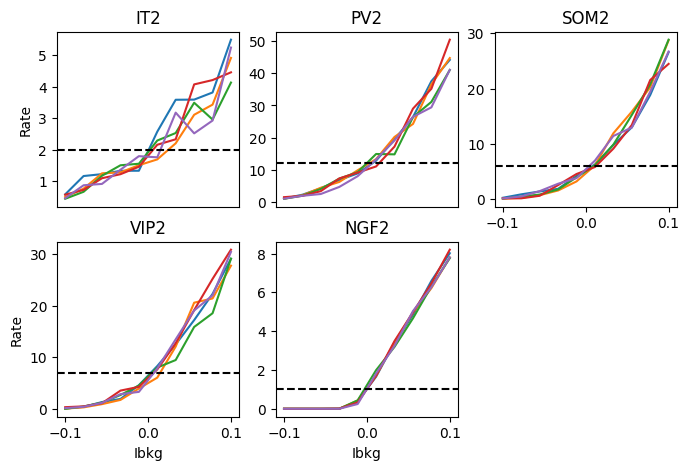

In [5]:
pops_vis = [pop for pop in R.pop.values if 'frz' not in pop]
Rvis = R['avg_rate'].sel(pop=pops_vis)

plt.figure(figsize=(8, 5))
for n, pop in enumerate(pops_vis):
    plt.subplot(2, 3, n + 1)
    for seed in R.seed_main:
        Rvis.sel(pop=pop, seed_main=seed).plot()
    plt.axhline(target_rates[pop], color='k', ls='--')
    xlabel = 'Ibkg' if n >= 3 else None
    ylabel = 'Rate' if n % 3 == 0 else None
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if n < 2: plt.xticks([])
    plt.title(pop)
